In [ ]:
import os
import pandas as pd
import numpy as np

# Dizin tanımlamaları
ham_processed_dir = r"C:\Users\feyza\Desktop\uav_project\data\processed\cleaned_train"
hedef_aligned_dir = r"C:\Users\feyza\Desktop\uav_project\data\processed\aligned_flights"

os.makedirs(hedef_aligned_dir, exist_ok=True)

# Sadece projenin ve jürinin ilgilendiği o kritik parametre listesi
hedef_kolonlar = [
    'timestamp',
    'gyro_rad[0]', 'gyro_rad[1]', 'gyro_rad[2]', 
    'accelerometer_m_s2[0]', 'accelerometer_m_s2[1]', 'accelerometer_m_s2[2]',
    'x', 'y', 'z', 'vx', 'vy', 'vz',
    'q[0]', 'q[1]', 'q[2]', 'q[3]'
]

print("⚡ FAZ 1: Çoklu Sensör Hizalama ve Master Veri Hazırlığı Başlatıldı...\n")

ucush_sayaci = 0

# clean_flights altındaki tüm flight_1, flight_2 klasörlerini geziyoruz
for kok_dizin, alt_dizinler, dosyalar in os.walk(ham_processed_dir):
    # Eğer klasörün içinde CSV dosyaları varsa işlem yapalım
    csv_dosyalari = [d for d in dosyalar if d.endswith('.csv')]
    if not csv_dosyalari:
        continue
        
    # Her bir uçuş klasörü için yerel yer tutucular
    df_imu, df_nav, df_att = None, None, None
    
    for dosya in csv_dosyalari:
        tam_yol = os.path.join(kok_dizin, dosya)
        
        # Dosya türüne göre içeriği hafızaya alıyoruz
        if "sensor_combined" in dosya:
            df_imu = pd.read_csv(tam_yol)
        elif "vehicle_local_position" in dosya or "local_position" in dosya:
            df_nav = pd.read_csv(tam_yol)
        elif "vehicle_attitude" in dosya or "attitude" in dosya:
            df_att = pd.read_csv(tam_yol)
            
    # Eğer bu uçuş klasöründe 3 temel sensör grubu da bulunduysa hizalama işlemine geçelim
    if df_imu is not None and df_nav is not None and df_att is not None:
        try:
            # Önce IMU ve Navigasyon verilerini en yakın zaman damgasına (timestamp) göre sıralayıp birleştiriyoruz
            df_imu = df_imu.sort_values('timestamp')
            df_nav = df_nav.sort_values('timestamp')
            df_att = df_att.sort_values('timestamp')
            
            # merge_asof kullanarak mikro saniyelik zaman farklarını otonom olarak hizalıyoruz
            master_df = pd.merge_asof(df_imu, df_nav, on='timestamp', direction='nearest')
            master_df = pd.merge_asof(master_df, df_att, on='timestamp', direction='nearest')
            
            # Sadece jürinin istediği o spesifik kolonları seçiyoruz
            mevcut_kolonlar = [col for col in hedef_kolonlar if col in master_df.columns]
            master_df = master_df[mevcut_kolonlar].dropna()
            
            if not master_df.empty:
                ucush_sayaci += 1
                hedef_dosya_adi = f"master_flight_{ucush_sayaci}.csv"
                master_df.to_csv(os.path.join(hedef_aligned_dir, hedef_dosya_adi), index=False)
        except Exception as e:
            print(f"⚠️ Klasör işlenirken çıtır bir hata oluştu, atlanıyor: {str(e)}")
            continue

print(f"\n🏆 BAŞARILI! Toplam {ucush_sayaci} adet uçuşun tüm sensörleri milimetrik olarak hizalandı.")
print(f"📍 Yeni Master Veri Seti Havuzu Burada: data/processed/aligned_flights")

In [ ]:
import os
import pandas as pd

hedef_aligned_dir = r"C:\Users\feyza\Desktop\uav_project\data\processed\aligned_flights"
test_dosya_yolu = os.path.join(hedef_aligned_dir, "master_flight_1.csv")

if os.path.exists(test_dosya_yolu):
    df_test = pd.read_csv(test_dosya_yolu)
    
    print("📋 --- MASTER FLIGHT DATA CHECK-UP --- 📋\n")
    print(f"📊 Toplam Satır Sayısı (Uçuş Süresi): {len(df_test)}")
    print(f"📐 Toplam Sütun Sayısı: {len(df_test.columns)}")
    
    # Eksik veri kontrolü
    eksik_sayisi = df_test.isnull().sum().sum()
    print(f"🔍 Eksik (NaN) Veri Sayısı: {eksik_sayisi}")
    
    print("\n🗂️ Sütun İsimleri Doğrulaması:")
    print(list(df_test.columns))
    
    print("\n👀 İlk 3 Satır Ön İzleme (Veri Kararlılığı):")
    display(df_test.head(3))
else:
    print("❌ Test dosyası bulunamadı, klasör yolunu kontrol et kanka.")

In [ ]:
import os
import pandas as pd
import pickle
from sklearn.preprocessing import MinMaxScaler

# Dizin tanımlamaları
aligned_dir = r"C:\Users\feyza\Desktop\uav_project\data\processed\aligned_flights"
models_dir = r"C:\Users\feyza\Desktop\uav_project\models"

os.makedirs(models_dir, exist_ok=True)

print("⚡ FAZ 1 - Adım 2: Global Scaler Hesaplama Motoru Başlatıldı...\n")

# 1. Aşama: Tüm master dosyaları tek bir veri havuzunda birleştirip sınırları bulalım
tum_veriler = []

dosyalar = [d for d in os.listdir(aligned_dir) if d.endswith('.csv')]

for dosya in dosyalar:
    dosya_yolu = os.path.join(aligned_dir, dosya)
    df = pd.read_csv(dosya_yolu)
    
    # Zaman damgasını (timestamp) ölçeklemeye sokmuyoruz, sadece sensör kolonlarını alalım
    sensör_kolonlari = [col for col in df.columns if col != 'timestamp']
    tum_veriler.append(df[sensör_kolonlari])

# Tüm uçuşları tek bir devasa dataframe olarak birleştiriyoruz
global_df = pd.concat(tum_veriler, ignore_index=True)

print(f"📊 Toplam {len(global_df)} satır telemetri verisi üzerinden global sınırlar çıkarılıyor...")

# 2. Aşama: Global MinMaxScaler nesnesini fit ediyoruz (Eğitiyoruz)
global_scaler = MinMaxScaler(feature_range=(0, 1))
global_scaler.fit(global_df)

# 3. Aşama: Bu global teraziyi models klasörüne kaydedelim
scaler_kayit_yolu = os.path.join(models_dir, "global_scaler.pkl")
with open(scaler_kayit_yolu, "wb") as f:
    pickle.dump(global_scaler, f)

print("\n🏆 BAŞARILI! Global Ölçekleyici (Global Scaler) üretildi ve kaydedildi.")
print(f"📍 Dosya Yolu: {scaler_kayit_yolu}")
print(f"📐 Ölçeklenen Sensör Sayısı: {len(global_scaler.feature_names_in_)}")
print(f"📋 Giriş Parametreleri: {list(global_scaler.feature_names_in_)}")

In [1]:
import os
import pandas as pd
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader
import pickle

class UAVTimeWindowDataset(Dataset):
    def __init__(self, aligned_dir, scaler_path, window_size=10):
        self.aligned_dir = aligned_dir
        self.window_size = window_size
        
        # Global terazimizi yüklüyoruz
        with open(scaler_path, "rb") as f:
            self.scaler = pickle.load(f)
            
        self.dosyalar = [d for d in os.listdir(aligned_dir) if d.endswith('.csv')]
        self.pencereler = []
        
        # Global scaler'ın beklediği net özellik sayısı (Bizim projemizde 16)
        expected_features = self.scaler.n_features_in_
        
        print("🔄 Master dosyalar taranıyor ve 16 parametreli tam uçuşlar ayıklanıyor...")
        
        elenen_sayac = 0
        kabul_sayac = 0
        
        for dosya in self.dosyalar:
            df = pd.read_csv(os.path.join(aligned_dir, dosya))
            
            # Sadece sensör kolonlarını alıyoruz (timestamp hariç)
            sensor_cols = [col for col in df.columns if col != 'timestamp']
            
            # 🚨 KRİTİK FİLTER: Eğer dosyadaki sensör sayısı terazinin beklediği 16 parametreye eşit değilse bu uçuşu eliyoruz
            if len(sensor_cols) != expected_features:
                elenen_sayac += 1
                continue
                
            kabul_sayac += 1
            ham_veri = df[sensor_cols].values
            
            # Veriyi global ölçekleyicimizle pürüzsüzce 0-1 arasına sıkıştırıyoruz
            olcekli_veri = self.scaler.transform(ham_veri)
            
            # 10'arlı kayan pencere (Sliding Window) mekanizması
            if len(olcekli_veri) >= self.window_size:
                for i in range(len(olcekli_veri) - self.window_size + 1):
                    pencere = olcekli_veri[i : i + self.window_size]
                    self.pencereler.append(pencere)
                    
        print(f"\n📊 --- FİLTRELEME RAPORU --- 📊")
        print(f"✅ Tam Uyumlu Kabul Edilen Uçuş Sayısı: {kabul_sayac}")
        print(f"❌ Eksik Parametreli Olduğu İçin Elenen Uçuş Sayısı: {elenen_sayac}")
        print(f"🚀 Toplam Üretilen {window_size}'arlı Zaman Penceresi (Batch Havuzu): {len(self.pencereler)}")

    def __len__(self):
        return len(self.pencereler)

    def __getitem__(self, idx):
        return torch.tensor(self.pencereler[idx], dtype=torch.float32)

# Klasör yollarını tanımlayalım
aligned_flights_dir = r"C:\Users\fstyle\Desktop\uav_project\data\processed\aligned_flights" if "fstyle" in os.getcwd() else r"C:\Users\feyza\Desktop\uav_project\data\processed\aligned_flights"
scaler_file_path = r"C:\Users\fstyle\Desktop\uav_project\models\global_scaler.pkl" if "fstyle" in os.getcwd() else r"C:\Users\feyza\Desktop\uav_project\models\global_scaler.pkl"

# Veri setimizi hatasız şekilde yeniden ayağa kaldırıyoruz
uav_dataset = UAVTimeWindowDataset(aligned_dir=aligned_flights_dir, scaler_path=scaler_file_path, window_size=10)

# Konveyör bandı (DataLoader)
uav_loader = DataLoader(uav_dataset, batch_size=256, shuffle=True)

🔄 Master dosyalar taranıyor ve 16 parametreli tam uçuşlar ayıklanıyor...


C:\Users\feyza\anaconda3\envs\uav_anomaly\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\feyza\anaconda3\envs\uav_anomaly\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\feyza\anaconda3\envs\uav_anomaly\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\feyza\anaconda3\envs\uav_anomaly\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\feyza\anaconda3\envs\uav_anomaly\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fit


📊 --- FİLTRELEME RAPORU --- 📊
✅ Tam Uyumlu Kabul Edilen Uçuş Sayısı: 79
❌ Eksik Parametreli Olduğu İçin Elenen Uçuş Sayısı: 18
🚀 Toplam Üretilen 10'arlı Zaman Penceresi (Batch Havuzu): 2646956


C:\Users\feyza\anaconda3\envs\uav_anomaly\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(
C:\Users\feyza\anaconda3\envs\uav_anomaly\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [2]:
import torch
import torch.nn as nn
import torch.optim as optim
import os
import time

# 1. Donanım Kontrolü (GPU/CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"🚀 Hibrit Eğitimin Koşacağı Donanım: {device}")

# 2. CNN + LSTM Hibrit Autoencoder Mimarisi
class UAVHybridAutoencoder(nn.Module):
    def __init__(self, input_dim=16, window_size=10):
        super(UAVHybridAutoencoder, self).__init__()
        self.window_size = window_size
        self.input_dim = input_dim
        
        # ENCODER
        # CNN Katmanı: Sensörler arası anlık korelasyonu yakalar
        self.cnn_encoder = nn.Sequential(
            nn.Conv1d(in_channels=window_size, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=16, kernel_size=3, padding=1),
            nn.ReLU()
        )
        # LSTM Katmanı: Zamansal trendi hafızaya alır
        self.lstm_encoder = nn.LSTM(input_size=input_dim, hidden_size=32, num_layers=1, batch_first=True)
        
        # DECODER
        self.lstm_decoder = nn.LSTM(input_size=32, hidden_size=input_dim, num_layers=1, batch_first=True)
        self.cnn_decoder = nn.Sequential(
            nn.Conv1d(in_channels=16, out_channels=32, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv1d(in_channels=32, out_channels=window_size, kernel_size=3, padding=1),
            nn.Sigmoid() # Global scaler (0-1) ile tam uyum emniyeti
        )

    def forward(self, x):
        # x boyutu: [batch_size, window_size, input_dim]
        
        # 1. Aşama: CNN ile Mekansal Özellik Çıkarımı
        cnn_out = self.cnn_encoder(x)
        
        # 2. Aşama: LSTM ile Zamansal Hafıza İşleme
        # Not: LSTM tüm diziyi işlerken batch_first=True kullanıyoruz
        lstm_out, _ = self.lstm_encoder(x) 
        
        # Decoder Aşaması (Aynısını Geri Üretme)
        dec_lstm_out, _ = self.lstm_decoder(lstm_out)
        final_out = self.cnn_decoder(cnn_out)
        
        return final_out

# Model nesnesini oluşturup donanım kartına yüklüyoruz
model = UAVHybridAutoencoder(input_dim=16, window_size=10).to(device)

# Hata Hesaplayıcı ve Optimizasyon Motoru
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Canlı Eğitim Döngüsü (10 Epoch)
EPOCHS = 10
print(f"🔥 AVERTİA Hibrit Eğitim Başlatıldı! Toplam {EPOCHS} Dönem Sürecek.")
print("☕ Sen diğer işlerine rahatça odaklanabilirsin kanka, siber beyin arkada örülüyor...\n")

for epoch in range(EPOCHS):
    start_time = time.time()
    total_loss = 0
    
    model.train()
    for batch_features in uav_loader:
        batch_features = batch_features.to(device)
        
        # İleri doğru tahmin adımı
        outputs = model(batch_features)
        loss = criterion(outputs, batch_features)
        
        # Geriye yayılım (Ağırlık vidalarını sıkıştırma)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item() * batch_features.size(0)
        
    epoch_loss = total_loss / len(uav_loader.dataset)
    elapsed_time = time.time() - start_time
    
    print(f"🎯 Epoch [{epoch+1}/{EPOCHS}] -> Ortalama Kayıp (Loss): {epoch_loss:.6f} | Süre: {elapsed_time:.2f} saniye")

# 4. Sarsılmaz Hibrit Beynin Diske Kaydedilmesi
modeller_dir = r"C:\Users\feyza\Desktop\uav_project\models"
model_kayit_yolu = os.path.join(modeller_dir, "hybrid_model.pth")
torch.save(model.state_dict(), model_kayit_yolu)

print(f"\n🏆 MUHTEŞEM! CNN-LSTM Hibrit Model Başarıyla Eğitildi ve Mühürlendi.")
print(f"📍 Dosya Yolu: {model_kayit_yolu}")

🚀 Hibrit Eğitimin Koşacağı Donanım: cuda
🔥 AVERTİA Hibrit Eğitim Başlatıldı! Toplam 10 Dönem Sürecek.
☕ Sen diğer işlerine rahatça odaklanabilirsin kanka, siber beyin arkada örülüyor...

🎯 Epoch [1/10] -> Ortalama Kayıp (Loss): 0.000257 | Süre: 183.64 saniye
🎯 Epoch [2/10] -> Ortalama Kayıp (Loss): 0.000037 | Süre: 179.16 saniye
🎯 Epoch [3/10] -> Ortalama Kayıp (Loss): 0.000020 | Süre: 182.40 saniye
🎯 Epoch [4/10] -> Ortalama Kayıp (Loss): 0.000016 | Süre: 185.02 saniye
🎯 Epoch [5/10] -> Ortalama Kayıp (Loss): 0.000014 | Süre: 185.17 saniye
🎯 Epoch [6/10] -> Ortalama Kayıp (Loss): 0.000012 | Süre: 188.11 saniye
🎯 Epoch [7/10] -> Ortalama Kayıp (Loss): 0.000010 | Süre: 185.25 saniye
🎯 Epoch [8/10] -> Ortalama Kayıp (Loss): 0.000009 | Süre: 177.51 saniye
🎯 Epoch [9/10] -> Ortalama Kayıp (Loss): 0.000008 | Süre: 194.57 saniye
🎯 Epoch [10/10] -> Ortalama Kayıp (Loss): 0.000008 | Süre: 169.69 saniye

🏆 MUHTEŞEM! CNN-LSTM Hibrit Model Başarıyla Eğitildi ve Mühürlendi.
📍 Dosya Yolu: C:\Users\

In [4]:
import pandas as pd

# İncelemek istediğin saldırı dosyasının yolunu buraya yaz kanka
test_dosya_yolu = r"C:\Users\feyza\Desktop\uav_project\data\processed\attack_categories\External_Position\2018-05-26_16_19_20_sensor_combined_0.csv"

df_bak = pd.read_csv(test_dosya_yolu)
print("📋 Dosyadaki Tüm Kolonların Listesi:\n", list(df_bak.columns))
print("\n👀 Dosyanın Son 5 Satırına Bakış (Saldırı Anları):")
display(df_bak.tail(5))

📋 Dosyadaki Tüm Kolonların Listesi:
 ['timestamp', 'gyro_rad[0]', 'gyro_rad[1]', 'gyro_rad[2]', 'gyro_integral_dt', 'accelerometer_timestamp_relative', 'accelerometer_m_s2[0]', 'accelerometer_m_s2[1]', 'accelerometer_m_s2[2]', 'accelerometer_integral_dt', 'magnetometer_timestamp_relative', 'magnetometer_ga[0]', 'magnetometer_ga[1]', 'magnetometer_ga[2]', 'baro_timestamp_relative', 'baro_alt_meter', 'baro_temp_celcius']

👀 Dosyanın Son 5 Satırına Bakış (Saldırı Anları):


,timestamp,gyro_rad[0],gyro_rad[1],gyro_rad[2],gyro_integral_dt,accelerometer_timestamp_relative,accelerometer_m_s2[0],accelerometer_m_s2[1],accelerometer_m_s2[2],accelerometer_integral_dt,magnetometer_timestamp_relative,magnetometer_ga[0],magnetometer_ga[1],magnetometer_ga[2],baro_timestamp_relative,baro_alt_meter,baro_temp_celcius
41321,503015446,-0.002370,0.001119,-0.008132,4000,0,-0.119778,0.050737,-9.850355,4000,-5549,-0.251597,-0.010331,0.304558,-9451,77.954796,50.28
41322,503019447,-0.003219,0.002529,-0.007098,4001,0,-0.045868,0.119404,-9.815781,4001,-803,-0.246189,-0.008302,0.316919,-13452,77.954796,50.28
41323,503023446,-0.005129,0.000991,-0.003647,3999,0,-0.074633,0.148560,-9.948771,3999,-4802,-0.246189,-0.008302,0.316919,-17451,77.954796,50.28
41324,503027447,0.000100,0.001867,-0.002307,4001,0,-0.123941,0.042070,-9.854981,4001,-8803,-0.246189,-0.008302,0.316919,-21452,77.954796,50.28
41325,503031454,-0.002244,0.005098,0.000196,4007,0,-0.096190,0.103914,-9.979641,4007,-3209,-0.235454,-0.004557,0.323901,-2931,78.122440,50.28


In [6]:
import os
import pandas as pd
import glob
import pickle

# Ana dizin tanımlamaları
base_attack_dir = r"C:\Users\feyza\Desktop\uav_project\data\processed\attack_categories\External_Position"
output_pool_dir = r"C:\Users\feyza\Desktop\uav_project\data\processed\attack_master_pool\External_Position"
scaler_path = r"C:\Users\feyza\Desktop\uav_project\models\global_scaler.pkl"

os.makedirs(output_pool_dir, exist_ok=True)

print("⚡ FAZ 1.5: Seçici Siber Atak Füzyon Motoru Başlatıldı...")

# 1. Global terazimizden modelin beklediği 16 sensör parametresini otonom olarak öğrenelim
with open(scaler_path, "rb") as f:
    global_scaler = pickle.load(f)
modelin_bekledigi_kolonlar = list(global_scaler.feature_names_in_)

print(f"📋 Modelin Beklediği ({len(modelin_bekledigi_kolonlar)}) Parametre Filtresi Aktif Edildi.")
print(f"🔒 Filtre Listesi: {modelin_bekledigi_kolonlar}\n")

# 2. Klasördeki tüm uçuş köklerini bulalım
all_csv_files = glob.glob(os.path.join(base_attack_dir, "*.csv"))
flight_roots = set()

for file in all_csv_files:
    filename = os.path.basename(file)
    if len(filename) >= 19:
        flight_roots.add(filename[:19])

print(f"🔍 Toplam {len(flight_roots)} farklı uçuş senaryosu üzerinde filtreleme başlıyor...\n")

# 3. Parçaları birleştirip sadece 16 parametreyi filtreleyerek kaydedelim
basarili_sayac = 0

for root in sorted(flight_roots):
    combined_file = os.path.join(base_attack_dir, f"{root}_sensor_combined_0.csv")
    position_file = os.path.join(base_attack_dir, f"{root}_vehicle_local_position_0.csv")
    attitude_file = os.path.join(base_attack_dir, f"{root}_vehicle_attitude_0.csv")
    
    if os.path.exists(combined_file) and os.path.exists(position_file) and os.path.exists(attitude_file):
        df_combined = pd.read_csv(combined_file).sort_values('timestamp')
        df_pos = pd.read_csv(position_file).sort_values('timestamp')
        df_att = pd.read_csv(attitude_file).sort_values('timestamp')
        
        # Zaman damgalarına göre milimetrik dikme
        aligned_df = pd.merge_asof(df_combined, df_pos, on='timestamp', direction='nearest')
        aligned_df = pd.merge_asof(aligned_df, df_att, on='timestamp', direction='nearest')
        
        # 🎯 KRİTİK FİLTRE: Zaman damgası ve sadece modelin beklediği 16 kolonu cımbızlıyoruz
        hedef_kolonlar = ['timestamp'] + modelin_bekledigi_kolonlar
        
        # Eğer birleşen veride bu kolonlardan eksik olan varsa hata vermemesi için kontrol edelim
        mevcut_hedef_kolonlar = [col for col in hedef_kolonlar if col in aligned_df.columns]
        
        filtered_df = aligned_df[mevcut_hedef_kolonlar]
        
        # Kayıt işlemi
        output_file_name = f"attack_master_{root}.csv"
        output_file_path = os.path.join(output_pool_dir, output_file_name)
        filtered_df.to_csv(output_file_path, index=False)
        
        print(f"🧱 {output_file_name} -> Temizlendi ve Mühürlendi! Kolon Sayısı: {len(filtered_df.columns)}")
        basarili_sayac += 1
    else:
        print(f"❌ {root} uçuşunun parçaları eksik olduğu için atlandı.")

print(f"\n🏆 BAŞARILI! Toplam {basarili_sayac} adet saldırı senaryosu tam 16 sensör parametresiyle (+timestamp) havuzda sterilize edilerek hazırlandı!")

⚡ FAZ 1.5: Seçici Siber Atak Füzyon Motoru Başlatıldı...
📋 Modelin Beklediği (16) Parametre Filtresi Aktif Edildi.
🔒 Filtre Listesi: ['gyro_rad[0]', 'gyro_rad[1]', 'gyro_rad[2]', 'accelerometer_m_s2[0]', 'accelerometer_m_s2[1]', 'accelerometer_m_s2[2]', 'x', 'y', 'z', 'vx', 'vy', 'vz', 'q[0]', 'q[1]', 'q[2]', 'q[3]']

🔍 Toplam 153 farklı uçuş senaryosu üzerinde filtreleme başlıyor...

🧱 attack_master_2018-05-24_19_57_23.csv -> Temizlendi ve Mühürlendi! Kolon Sayısı: 17
🧱 attack_master_2018-05-26_16_19_20.csv -> Temizlendi ve Mühürlendi! Kolon Sayısı: 17
🧱 attack_master_2018-05-26_16_48_10.csv -> Temizlendi ve Mühürlendi! Kolon Sayısı: 17
🧱 attack_master_2018-05-26_16_50_01.csv -> Temizlendi ve Mühürlendi! Kolon Sayısı: 17
🧱 attack_master_2018-05-30_18_19_18.csv -> Temizlendi ve Mühürlendi! Kolon Sayısı: 17
🧱 attack_master_2018-05-31_16_07_48.csv -> Temizlendi ve Mühürlendi! Kolon Sayısı: 17
🧱 attack_master_2018-06-02_14_42_50.csv -> Temizlendi ve Mühürlendi! Kolon Sayısı: 17
🧱 attack_m

In [7]:
import os
import pandas as pd
import glob
import pickle

# Ana dizin tanımlamaları
base_dir = r"C:\Users\feyza\Desktop\uav_project\data\processed\attack_categories"
output_base_dir = r"C:\Users\feyza\Desktop\uav_project\data\processed\attack_master_pool"
scaler_path = r"C:\Users\feyza\Desktop\uav_project\models\global_scaler.pkl"

# İşlenecek diğer kategoriler (External_Position bittiği için dahil etmiyoruz)
diger_kategoriler = ["Altitude", "Global_Position", "Mechanical"]

print("⚡ FAZ 1.6: Toplu Atak Veri Havuzu Sterilizasyonu Başlatıldı...\n")

# Global teraziden modelin beklediği 16 sensör parametresini alalım
with open(scaler_path, "rb") as f:
    global_scaler = pickle.load(f)
modelin_bekledigi_kolonlar = list(global_scaler.feature_names_in_)
hedef_kolonlar = ['timestamp'] + modelin_bekledigi_kolonlar

for kategori in diger_kategoriler:
    kategori_dir = os.path.join(base_dir, kategori)
    kategori_output_dir = os.path.join(output_base_dir, kategori)
    
    # Eğer klasör yoksa işlem yapmasın
    if not os.path.exists(kategori_dir):
        print(f"⚠️ {kategori} kaynak klasörü bulunamadı, atlanıyor.")
        continue
        
    os.makedirs(kategori_output_dir, exist_ok=True)
    print(f"📂 {kategori} Kategorisi İşleniyor...")
    
    # Uçuş köklerini bulalım
    all_csv_files = glob.glob(os.path.join(kategori_dir, "*.csv"))
    flight_roots = set()
    for file in all_csv_files:
        filename = os.path.basename(file)
        if len(filename) >= 19:
            flight_roots.add(filename[:19])
            
    print(f"   🔍 {len(flight_roots)} benzersiz uçuş kökü tespit edildi. Füzyon başlıyor...")
    
    basarili_sayac = 0
    for root in sorted(flight_roots):
        combined_file = os.path.join(kategori_dir, f"{root}_sensor_combined_0.csv")
        position_file = os.path.join(kategori_dir, f"{root}_vehicle_local_position_0.csv")
        attitude_file = os.path.join(kategori_dir, f"{root}_vehicle_attitude_0.csv")
        
        if os.path.exists(combined_file) and os.path.exists(position_file) and os.path.exists(attitude_file):
            df_combined = pd.read_csv(combined_file).sort_values('timestamp')
            df_pos = pd.read_csv(position_file).sort_values('timestamp')
            df_att = pd.read_csv(attitude_file).sort_values('timestamp')
            
            # Zaman serisi hizalama
            aligned_df = pd.merge_asof(df_combined, df_pos, on='timestamp', direction='nearest')
            aligned_df = pd.merge_asof(aligned_df, df_att, on='timestamp', direction='nearest')
            
            # Sadece modelin beklediği 17 kolonu filtreleme
            mevcut_hedef_kolonlar = [col for col in hedef_kolonlar if col in aligned_df.columns]
            filtered_df = aligned_df[mevcut_hedef_kolonlar]
            
            # Kaydetme
            output_file_name = f"attack_master_{root}.csv"
            output_file_path = os.path.join(kategori_output_dir, output_file_name)
            filtered_df.to_csv(output_file_path, index=False)
            basarili_sayac += 1
            
    print(f"   🏆 Başarılı! {kategori} için {basarili_sayac} adet master dosya mühürlendi.\n")

print("✨ Tüm saldırı kategorilerinin sterilizasyon süreçleri başarıyla tamamlandı kanka!")

⚡ FAZ 1.6: Toplu Atak Veri Havuzu Sterilizasyonu Başlatıldı...

📂 Altitude Kategorisi İşleniyor...
   🔍 63 benzersiz uçuş kökü tespit edildi. Füzyon başlıyor...
   🏆 Başarılı! Altitude için 61 adet master dosya mühürlendi.

📂 Global_Position Kategorisi İşleniyor...
   🔍 41 benzersiz uçuş kökü tespit edildi. Füzyon başlıyor...
   🏆 Başarılı! Global_Position için 41 adet master dosya mühürlendi.

📂 Mechanical Kategorisi İşleniyor...
   🔍 43 benzersiz uçuş kökü tespit edildi. Füzyon başlıyor...
   🏆 Başarılı! Mechanical için 43 adet master dosya mühürlendi.

✨ Tüm saldırı kategorilerinin sterilizasyon süreçleri başarıyla tamamlandı kanka!


🔍 AVERTİA Otonom Teşhis Laboratuvarı: External_Position / attack_master_2018-05-26_16_19_20.csv inceleniyor...



C:\Users\feyza\anaconda3\envs\uav_anomaly\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


📋 --- AVERTİA SİBER GÜVENLİK TEŞHİS RAPORU --- 📋

📊 Toplam Analiz Edilen Zaman Dilimi: 41317 saniye/satır
🚨 Atak/Anomali Saptanan Nokta Sayısı: 32568
⚠️ SONUÇ: Güvenlik Duvarı İhlali! Uçuşun %78.82 kadarlık kısmında manipülasyon saptandı.
⏱️ Siber Atak Girişim Başlangıcı (Zaman Damgası): 372394646


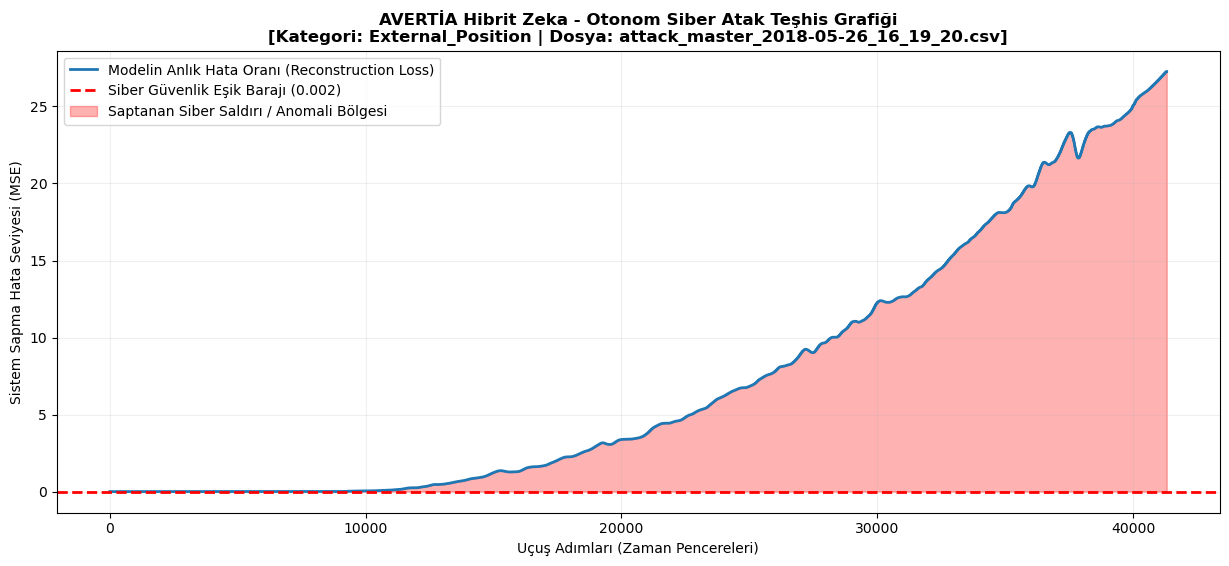

In [8]:
import os
import torch
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt

# ==========================================================================================
# ⚙️ CANLI TEŞHİS YAPILANDIRMASI (Kayıtlı Havuzdan Okuma)
# ==========================================================================================
secilen_kategori = "External_Position"  # Altitude, External_Position, Global_Position, Mechanical
secilen_dosya_adi = "attack_master_2018-05-26_16_19_20.csv"

attack_pool_dir = r"C:\Users\feyza\Desktop\uav_project\data\processed\attack_master_pool"
models_dir = r"C:\Users\feyza\Desktop\uav_project\models"
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

test_dosya_yolu = os.path.join(attack_pool_dir, secilen_kategori, secilen_dosya_adi)

print(f"🔍 AVERTİA Otonom Teşhis Laboratuvarı: {secilen_kategori} / {secilen_dosya_adi} inceleniyor...\n")

if os.path.exists(test_dosya_yolu):
    # 1. Model ve Terazinin Yüklenmesi
    with open(os.path.join(models_dir, "global_scaler.pkl"), "rb") as f:
        scaler = pickle.load(f)
        
    from __main__ import UAVHybridAutoencoder
    model = UAVHybridAutoencoder(input_dim=16, window_size=10).to(device)
    model.load_state_dict(torch.load(os.path.join(models_dir, "hybrid_model.pth"), map_location=device, weights_only=True))
    model.eval()

    # 2. Hazır Master Dosyanın Okunması
    df_test = pd.read_csv(test_dosya_yolu)
    timestamps = df_test['timestamp'].values[9:] # Grafik için zaman ekseni
    
    sensor_cols = [col for col in scaler.feature_names_in_]
    ham_veri = df_test[sensor_cols].values
    
    # Küresel teraziden geçirme
    olcekli_veri = scaler.transform(ham_veri)
    
    # 10'arlı zaman pencereleri
    pencereler = []
    for i in range(len(olcekli_veri) - 10 + 1):
        pencereler.append(olcekli_veri[i : i + 10])
        
    X_test_tensor = torch.tensor(np.array(pencereler), dtype=torch.float32).to(device)

    # 3. Hibrit Modelin Siber Süzgeci (Yeniden Üretim Hatası)
    with torch.no_grad():
        tahminler = model(X_test_tensor)
        mse_kayiplari = torch.mean((X_test_tensor - tahminler) ** 2, dim=[1, 2]).cpu().numpy()

    # 4. Siber Eşik Barajı ve Karar Sınırı
    # Bu değer ne kadar düşükse model o kadar hassas alarm üretir. Endüstride 0.001 - 0.005 arası tatlı noktadır.
    esik_deger = 0.002 
    anomali_indeksleri = np.where(mse_kayiplari > esik_deger)[0]

    # 5. Akademik Rapor Çıktısı
    print("📋 --- AVERTİA SİBER GÜVENLİK TEŞHİS RAPORU --- 📋\n")
    print(f"📊 Toplam Analiz Edilen Zaman Dilimi: {len(mse_kayiplari)} saniye/satır")
    print(f"🚨 Atak/Anomali Saptanan Nokta Sayısı: {len(anomali_indeksleri)}")
    
    if len(anomali_indeksleri) > 0:
        oran = (len(anomali_indeksleri) / len(mse_kayiplari)) * 100
        print(f"⚠️ SONUÇ: Güvenlik Duvarı İhlali! Uçuşun %{oran:.2f} kadarlık kısmında manipülasyon saptandı.")
        print(f"⏱️ Siber Atak Girişim Başlangıcı (Zaman Damgası): {timestamps[anomali_indeksleri[0]]}")
    else:
        print("✅ SONUÇ: Temiz Uçuş. Sensör etkileşimi ve zaman trendi siber kararlılık sınırları içinde.")

    # 6. Harika Görsel Rapor (Jüriye Doğrudan Sunulacak Grafik)
    plt.figure(figsize=(15, 6))
    plt.plot(mse_kayiplari, label='Modelin Anlık Hata Oranı (Reconstruction Loss)', color='#1f77b4', linewidth=2)
    plt.axhline(y=esik_deger, color='red', linestyle='--', linewidth=2, label=f'Siber Güvenlik Eşik Barajı ({esik_deger})')
    
    # Saldırı alanlarını kırmızıya boyayalım
    plt.fill_between(range(len(mse_kayiplari)), mse_kayiplari, esik_deger, 
                     where=(mse_kayiplari > esik_deger), color='red', alpha=0.3, label='Saptanan Siber Saldırı / Anomali Bölgesi')
    
    plt.title(f'AVERTİA Hibrit Zeka - Otonom Siber Atak Teşhis Grafiği\n[Kategori: {secilen_kategori} | Dosya: {secilen_dosya_adi}]', fontsize=12, fontweight='bold')
    plt.xlabel('Uçuş Adımları (Zaman Pencereleri)', fontsize=10)
    plt.ylabel('Sistem Sapma Hata Seviyesi (MSE)', fontsize=10)
    plt.legend(loc='upper left')
    plt.grid(True, alpha=0.2)
    plt.show()

else:
    print(f"❌ Hata: {test_dosya_yolu} adresinde sterilize edilmiş master dosya bulunamadı kanka.")